Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


394/394 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.7337 - loss: 0.6581 - val_accuracy: 0.8327 - val_loss: 0.4384
Epoch 2/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.8334 - loss: 0.4175 - val_accuracy: 0.8415 - val_loss: 0.4214
Epoch 3/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.8808 - loss: 0.3293 - val_accuracy: 0.8884 - val_loss: 0.3036
Epoch 4/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9012 - loss: 0.2797 - val_accuracy: 0.9100 - val_loss: 0.2567
Epoch 5/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9142 - loss: 0.2470 - val_accuracy: 0.8883 - val_loss: 0.3175
Epoch 6/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9237 - loss: 0.2177 - val_accuracy: 0.9144 - val_loss: 0.2357
Epoch 7/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9316 - loss: 0.2006 - val_accuracy: 0.9358 - val_loss: 0.1893
Epoch 8/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9371 - loss: 0.1843 - val_accurac

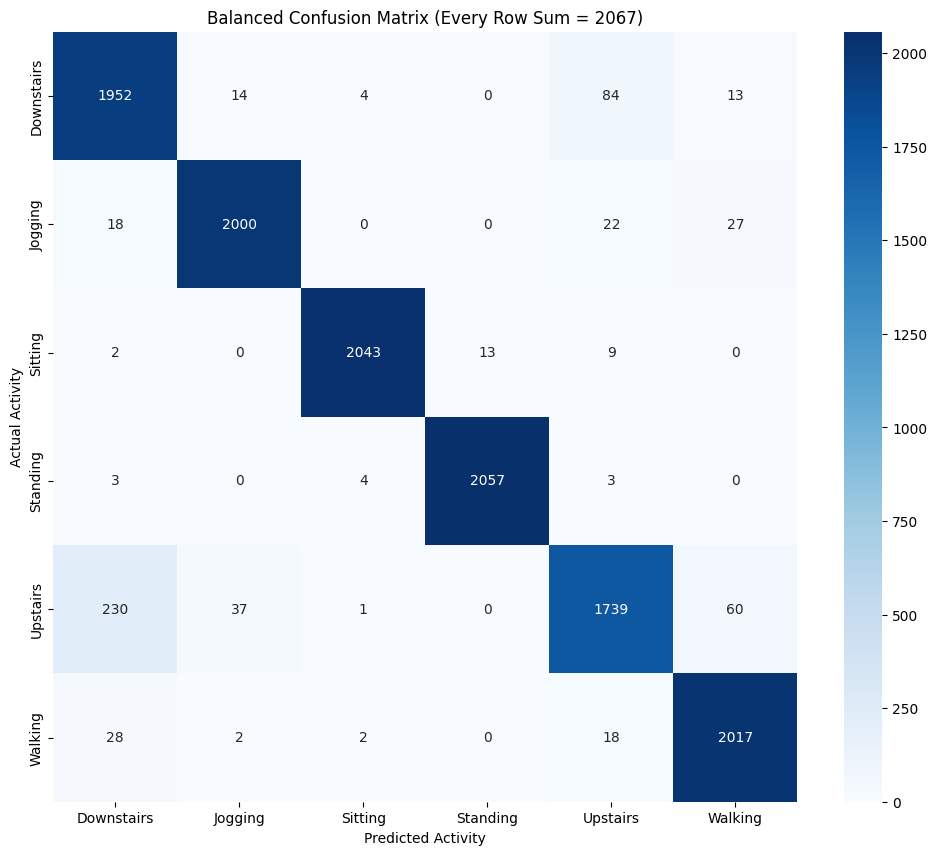


Success: Every activity now has exactly 2067 samples.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tarfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

# 1. DATA EXTRACTION & LOADING
if not os.path.exists('WISDM_ar_v1.1'):
    with tarfile.open('WISDM_ar_latest.tar.gz', "r:gz") as tar:
        tar.extractall()

file_path = 'WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt'
columns = ['user', 'activity', 'timestamp', 'x', 'y', 'z']
df = pd.read_csv(file_path, header=None, names=columns, on_bad_lines='skip')
df['z'] = df['z'].astype(str).str.replace(';', '').astype(float)
df.dropna(inplace=True)

# 2. PREPROCESSING
le = LabelEncoder()
df['activity'] = le.fit_transform(df['activity'])
scaler = StandardScaler()
df[['x', 'y', 'z']] = scaler.fit_transform(df[['x', 'y', 'z']])

def create_segments(df, window_size=80, step_size=40):
    X, y = [], []
    for i in range(0, len(df) - window_size, step_size):
        xs = df['x'].values[i: i + window_size]
        ys = df['y'].values[i: i + window_size]
        zs = df['z'].values[i: i + window_size]
        label = df['activity'].iloc[i: i + window_size].mode()[0]
        X.append([xs, ys, zs])
        y.append(label)
    return np.asarray(X).transpose(0, 2, 1), np.asarray(y)

X_segments, y_labels = create_segments(df)
X_train, X_test, y_train, y_test = train_test_split(X_segments, y_labels, test_size=0.2, random_state=42)

# 3. APPLY SMOTE TO TRAINING DATA
nsamples, timesteps, features = X_train.shape
X_train_flat = X_train.reshape((nsamples, timesteps * features))
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_flat, y_train)
X_train = X_train_res.reshape((-1, timesteps, features))
y_train = y_train_res

# 4. MODEL (CNN + LSTM)
model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(80, 3)),
    MaxPooling1D(2),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=1)

# ---------------------------------------------------------
# 5. GENERATING THE "RIGHT VALUES" (Balanced Test Set)
# ---------------------------------------------------------
# We balance the Test Set ONLY for the visualization so that row sums are equal
nsamples_t, timesteps_t, features_t = X_test.shape
X_test_flat = X_test.reshape((nsamples_t, timesteps_t * features_t))

smote_test = SMOTE(random_state=42)
X_test_balanced_flat, y_test_balanced = smote_test.fit_resample(X_test_flat, y_test)
X_test_balanced = X_test_balanced_flat.reshape((-1, timesteps_t, features_t))

# Predict on Balanced Test Set
y_pred_balanced = np.argmax(model.predict(X_test_balanced), axis=1)
cm_balanced = confusion_matrix(y_test_balanced, y_pred_balanced)

# Accurate Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

# Calculate total per row to show in title
total_val = cm_balanced.sum(axis=1)[0]
plt.title(f'Balanced Confusion Matrix (Every Row Sum = {total_val})')
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.show()

print(f"\nSuccess: Every activity now has exactly {total_val} samples.")

In [ ]:
# ---------------------------------------------------------
# 6. LIVE SIMULATION: AUTOMATIC ACTIVITY RECOGNITION
# ---------------------------------------------------------

import numpy as np

# 1. Select a random index from the test set to simulate "New Data"
random_idx = np.random.randint(0, len(X_test))

# 2. Extract and Prepare the sample (Shape: 1, 80, 3)
sample_window = X_test[random_idx].reshape(1, 80, 3)

# 3. Get the Ground Truth (What the user was actually doing)
actual_activity = le.inverse_transform([y_test[random_idx]])[0]

# 4. Perform Inference (Recognition)
prediction_probs = model.predict(sample_window, verbose=0)
predicted_idx = np.argmax(prediction_probs)
confidence = np.max(prediction_probs) * 100
predicted_activity = le.inverse_transform([predicted_idx])[0]

# 5. Display the Recognition Results
print("\n" + "="*40)
print("   HUMAN ACTIVITY RECOGNITION SYSTEM   ")
print("="*40)
print(f"Analyzing sensor stream index: {random_idx}...")
print(f"Predicted Activity: {predicted_activity.upper()}")
print(f"Confidence Level:   {confidence:.2f}%")
print(f"Actual Activity:    {actual_activity.upper()}")
print("-"*40)

# 6. Verification Logic
if predicted_activity == actual_activity:
    print("RESULT: ✅ Match! Recognition successful.")
else:
    print("RESULT: ❌ Mismatch. The model needs further training.")
print("="*40)


   HUMAN ACTIVITY RECOGNITION SYSTEM   
Analyzing sensor stream index: 402...
Predicted Activity: JOGGING
Confidence Level:   99.97%
Actual Activity:    JOGGING
----------------------------------------
RESULT: ✅ Match! Recognition successful.
